# Drifting Orbit and Scanner Validation: Terra MODIS

This notebook validates TAT-C against the [Moderate Resolution Imaging Spectroradiometer (MODIS)](https://modis.gsfc.nasa.gov/) aboard NASA's Terra satellite. MODIS is a 36-band radiometer with a double-sided scan mirror that sweeps across track within 55 deg of nadir every 1.477 s, imaging 10 rows of 1 km pixels per scan over a swath about 2,330 km wide. Terra was launched in 1999 into a sun-synchronous orbit at 705 km altitude with a descending node at 10:30 local time. Its last inclination adjustment was in 2020 and it was lowered in 2022; since then, the Sun's gravity has slowly changed its inclination, so its local time drifts, faster each year.

TAT-C represents MODIS as a `PointedInstrument` in scan geometry (`view_geometry=ViewGeometry.SCAN`), whose angular extent along track is constant across the scan (the "bow tie" effect, previously validated for VIIRS in [Imager Validation: NOAA-20 VIIRS](ValidateImagerVIIRS.ipynb)), and Terra's orbit by its two-line element (TLE) set, propagated with SGP4. This notebook asks:

1. **Orbit.** Does TAT-C's propagation of the TLE reproduce Terra's position?
2. **Local time drift.** Does a TLE reproduce the drift of Terra's local time, and over what period?
3. **Scan geometry.** What are MODIS's scan angles, velocity frame, and along-track extent, and does a scan-geometry view reproduce its pixels and scan footprints?
4. **Daily observations.** Does `collect_observations` predict which points MODIS observes in a day, and when?

## Reference Data

The MODIS/Terra geolocation product (`MOD03`, Collection 7) from the [Level-1 and Atmosphere Archive and Distribution System](https://ladsweb.modaps.eosdis.nasa.gov/) (LAADS DAAC) provides one netCDF file per 5-minute granule of 203 scans, with the time of each scan, Terra's Earth-fixed position and velocity, and the geodetic latitude, longitude, and terrain height of each 1 km pixel (10 detectors by 1,354 frames per scan). Its attributes also give the time and longitude of the orbit's equator crossing. Two sets of data are reduced with HTTP range requests (read with `h5py`):

* all 289 granules of 4 October 2026 (about 20 MB each): the scan times and navigation, and the geolocation of the first and last detectors of every scan at every eighth frame;
* the equator crossings from the attributes of one granule every 15 days from January 2018 (211 granules).

Downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package; the first run transfers about 6 GB and takes about 30 minutes, and the reduced data are cached in a local `data/modis` directory. Terra's orbit is taken from its TLE from [CelesTrak](https://celestrak.org/) (epoch 6 October 2026, 07:11 UTC).

In [1]:
import concurrent.futures
import io
from datetime import datetime, timedelta, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "modis"
DATA_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 4, tzinfo=timezone.utc)
FRAME_STEP = 8
GEO = "HDFEOS/SWATHS/MODIS_Swath_Type_GEO/"
TLE = [
    "1 25994U 99068A   26279.29978334  .00000220  00000+0  53719-4 0  9994",
    "2 25994  97.9333 324.3740 0001348 204.7527 222.4948 14.61170513425833",
]

_sessions = []


def https_session():
    """An authenticated Earthdata HTTPS session, logging in on first use."""
    if not _sessions:
        import earthaccess

        earthaccess.login()
        _sessions.append(earthaccess.get_requests_https_session())
    return _sessions[0]


class RemoteFile(io.RawIOBase):
    """Read-only file object that downloads blocks of a remote file with HTTP range requests on demand."""

    def __init__(self, url, block_size=2**20, prefetch=1):
        self.block_size, self.blocks, self.position = block_size, {}, 0
        response = self._get(url, 0, prefetch * block_size)
        self.url, self.size = response.url, int(response.headers["Content-Range"].split("/")[1])
        self._store(0, response.content)

    def _get(self, url, start, end):
        for attempt in range(5):
            try:
                response = https_session().get(url, headers={"Range": f"bytes={start}-{end - 1}"}, timeout=300)
                response.raise_for_status()
                return response
            except requests.RequestException:
                if attempt == 4:
                    raise

    def _store(self, first, content):
        for i in range(0, len(content), self.block_size):
            self.blocks[first + i // self.block_size] = content[i : i + self.block_size]

    def readable(self):
        return True

    def seekable(self):
        return True

    def tell(self):
        return self.position

    def seek(self, offset, whence=io.SEEK_SET):
        self.position = {io.SEEK_SET: 0, io.SEEK_CUR: self.position, io.SEEK_END: self.size}[whence] + offset
        return self.position

    def readinto(self, buffer):
        n = min(len(buffer), self.size - self.position)
        if n <= 0:
            return 0
        first, last = self.position // self.block_size, (self.position + n - 1) // self.block_size
        missing = [block for block in range(first, last + 1) if block not in self.blocks]
        if missing:
            end = min((missing[-1] + 1) * self.block_size, self.size)
            self._store(missing[0], self._get(self.url, missing[0] * self.block_size, end).content)
        data = b"".join(self.blocks[block] for block in range(first, last + 1))
        offset = self.position - first * self.block_size
        buffer[:n] = data[offset : offset + n]
        self.position += n
        return n


def attribute(f, name):
    value = f.attrs[name]
    if isinstance(value, bytes):
        return value.decode()
    return value.item() if np.ndim(value) == 0 or np.size(value) == 1 else value


def reduce_granule(url):
    """Scan times, navigation, and the first and last detector rows of every scan at every 8th frame."""
    path = DATA_DIR / url.rsplit("/", 1)[1].replace(".nc", ".npz")
    if path.exists():
        return path
    frames = np.r_[np.arange(0, 1354, FRAME_STEP), 1353]
    with h5py.File(RemoteFile(url), "r") as f:
        n_scans = int(attribute(f, "Number of Scans"))
        rows = np.sort(np.r_[np.arange(n_scans) * 10, np.arange(n_scans) * 10 + 9])

        def grid(name, scale=1.0):
            values = f[GEO + name][:][rows][:, frames].astype(np.float32)
            values[values <= -999] = np.nan
            return values * scale

        np.savez_compressed(
            path,
            start=attribute(f, "RangeBeginningDate") + "T" + attribute(f, "RangeBeginningTime"),
            ev_center_time=f["EV center time"][:],
            orb_pos=f["orb_pos"][:],
            orb_vel=f["orb_vel"][:],
            attitude_angles=f["attitude_angles"][:],
            scan_quality=f["Geo scan quality"][:],
            day_night=attribute(f, "DayNightFlag"),
            rows=rows,
            frames=frames,
            latitude=grid("Geolocation Fields/Latitude"),
            longitude=grid("Geolocation Fields/Longitude"),
            height=grid("Data Fields/Height"),
            sensor_zenith=grid("Data Fields/SensorZenith", 0.01),
        )
    return path


def crossing(url):
    """The equator crossing of the orbit of a granule, from its attributes."""
    with h5py.File(RemoteFile(url), "r") as f:
        return {
            "granule": url.rsplit("/", 1)[1],
            "date": attribute(f, "EquatorCrossingDate"),
            "time": attribute(f, "EquatorCrossingTime"),
            "longitude": float(attribute(f, "EquatorCrossingLongitude")),
            "orbit": int(attribute(f, "OrbitNumber")),
        }


def url_of(result):
    return next(link["URL"] for link in result["umm"]["RelatedUrls"] if link["URL"].startswith("https://data.laads"))


crossings_file = DATA_DIR / "equator_crossings.csv"
if not crossings_file.exists():
    import earthaccess

    urls, day = [], datetime(2018, 1, 1, tzinfo=timezone.utc)
    while day < DAY:
        found = earthaccess.search_data(short_name="MOD03", version="7", temporal=(day.strftime("%Y-%m-%dT%H:%M:%SZ"), (day + timedelta(minutes=4)).strftime("%Y-%m-%dT%H:%M:%SZ")), count=1)
        urls += [url_of(found[0])] if found else []
        day += timedelta(days=15)
    with concurrent.futures.ThreadPoolExecutor(6) as pool:
        pd.DataFrame(list(pool.map(crossing, urls))).to_csv(crossings_file, index=False)
if not any(DATA_DIR.glob("MOD03.*.npz")):
    import earthaccess

    found = earthaccess.search_data(short_name="MOD03", version="7", temporal=(DAY.strftime("%Y-%m-%dT%H:%M:%SZ"), (DAY + timedelta(days=1) - timedelta(seconds=1)).strftime("%Y-%m-%dT%H:%M:%SZ")))
    with concurrent.futures.ThreadPoolExecutor(6) as pool:
        list(pool.map(reduce_granule, sorted(url_of(r) for r in found)))

crossings = pd.read_csv(crossings_file)
crossings["time"] = pd.to_datetime(crossings.date + " " + crossings.time.str[:15]).dt.tz_localize("UTC")
crossings["local time (h)"] = ((crossings.time - crossings.time.dt.normalize()).dt.total_seconds() / 3600 + crossings.longitude / 15) % 24
granules = []
for path in sorted(DATA_DIR.glob("MOD03.*.npz")):
    with np.load(path) as d:
        granule = {key: d[key] for key in d.files}
    granule["name"] = path.stem
    valid = np.all(np.isfinite(granule["orb_pos"]), axis=1) & (np.linalg.norm(granule["orb_pos"], axis=1) > 6e6)
    granule["valid"] = valid
    granules.append(granule)
pd.Series(
    {
        "granules (4 October 2026)": len(granules),
        "scans": sum(len(g["ev_center_time"]) for g in granules),
        "day granules": sum(str(g["day_night"]) == "Day" for g in granules),
        "equator crossings": len(crossings),
        "first crossing": crossings.time.min(),
        "last crossing": crossings.time.max(),
    }
)

granules (4 October 2026)                                 289
scans                                                   58694
day granules                                              127
equator crossings                                         211
first crossing               2018-01-01 00:10:40.653147+00:00
last crossing                2026-09-30 23:30:56.679060+00:00
dtype: object

## Setup

MODIS scan times are given in seconds since 1 January 1993 in International Atomic Time (TAI), converted to UTC with Skyfield.

In [2]:
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.spatial import cKDTree
from skyfield.api import wgs84
from skyfield.framelib import itrs
from skyfield.positionlib import Geocentric
from skyfield.units import Distance, Velocity

from tatc.analysis import collect_observations
from tatc.constants import timescale
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite, SunSynchronousOrbit
from tatc.utils import (
    VelocityFrame,
    ViewGeometry,
    compute_projected_ray_position,
    compute_view_angles,
    geodesic_distance,
)

orbit = GeneralPerturbationsOrbit.from_tle(TLE)
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})


def scan_times(granule, scans=slice(None)):
    """Skyfield times of a granule's scans (EV center times, TAI seconds since 1993)."""
    return timescale.tai(1993, 1, 1, 0, 0, 26 + granule["ev_center_time"][scans].astype(float))


def ephemeris_track(granule, scans):
    """Terra's reported (Earth-fixed) position and velocity at scans, as an inertial orbit track."""
    return Geocentric.from_time_and_frame_vectors(
        scan_times(granule, scans), itrs, Distance(m=granule["orb_pos"][scans].T.astype(float)), Velocity(km_per_s=granule["orb_vel"][scans].T.astype(float) / 1e3)
    )

## Test 1: Orbit

The TLE is propagated (SGP4) to every tenth scan of the day and compared with the reported positions in the along-track, cross-track, and radial directions.

In [3]:
records = []
for g in granules:
    scans = np.nonzero(g["valid"])[0][::10]
    if len(scans) == 0:
        continue
    t = scan_times(g, scans)
    tle_xyz = orbit.get_orbit_track(list(t.utc_datetime())).frame_xyz(itrs).m
    reported, velocity = g["orb_pos"][scans].T.astype(float), g["orb_vel"][scans].T.astype(float)
    radial = reported / np.linalg.norm(reported, axis=0)
    cross = np.cross(reported, velocity, axis=0)
    cross /= np.linalg.norm(cross, axis=0)
    along = np.cross(cross, radial, axis=0)
    difference = (tle_xyz - reported) / 1e3
    records.append(pd.DataFrame({"along-track (km)": np.sum(difference * along, axis=0), "cross-track (km)": np.sum(difference * cross, axis=0), "radial (km)": np.sum(difference * radial, axis=0), "total (km)": np.linalg.norm(difference, axis=0)}))
errors = pd.concat(records)
errors.describe(percentiles=[0.5, 0.95]).loc[["mean", "50%", "95%", "max"]].round(3)

,along-track (km),cross-track (km),radial (km),total (km)
mean,-7.610,0.002,-0.003,7.613
50%,-7.634,-0.005,-0.001,7.637
95%,-6.622,0.233,0.240,8.466
max,-6.491,0.325,0.341,8.629


The propagated TLE trails Terra's reported position by 7.6 km along track (about 1.1 s), consistently over the day, which is about two days before the TLE epoch; the cross-track and radial differences are within 0.35 km.

## Test 2: Local Time Drift

The local time of an equator crossing is its universal time plus its longitude (15 deg per hour). The reported crossings (descending, on the day side) are compared with those of the TLE, propagated forward and backward with SGP4 from its epoch, by locating the descending equator crossing of the propagated orbit nearest each reported one; and with a `SunSynchronousOrbit` designed for the 10:30 descending node.

In [4]:
def tle_crossing(time):
    """Time and local time of the TLE orbit's descending equator crossing nearest a time."""
    seconds = np.arange(-3000, 3001, 10)
    track = orbit.get_orbit_track([time.to_pydatetime() + timedelta(seconds=float(s)) for s in seconds])
    xyz = track.frame_xyz(itrs).m
    k = np.nonzero((xyz[2, :-1] > 0) & (xyz[2, 1:] <= 0))[0]
    k = k[np.argmin(np.abs(seconds[k]))]
    fraction = xyz[2, k] / (xyz[2, k] - xyz[2, k + 1])
    crossing_time = time + pd.Timedelta(seconds=float(seconds[k] + 10 * fraction))
    longitude = np.degrees(np.arctan2(*(xyz[1, k] + fraction * (xyz[1, k + 1] - xyz[1, k]), xyz[0, k] + fraction * (xyz[0, k + 1] - xyz[0, k]))))
    return crossing_time, ((crossing_time - crossing_time.normalize()).total_seconds() / 3600 + longitude / 15) % 24


crossings["TAT-C (TLE) local time (h)"] = [tle_crossing(t)[1] for t in crossings.time]
crossings["TAT-C minus reported (min)"] = 60 * (crossings["TAT-C (TLE) local time (h)"] - crossings["local time (h)"])
crossings["years from TLE epoch"] = (crossings.time - pd.Timestamp(orbit.get_epoch())).dt.total_seconds() / (365.25 * 86400)
yearly = crossings.groupby(crossings.time.dt.year).agg(
    **{
        "reported local time (h)": ("local time (h)", "mean"),
        "reported drift (min/year)": ("local time (h)", lambda x: np.nan),
        "TAT-C (TLE) local time (h)": ("TAT-C (TLE) local time (h)", "mean"),
        "TAT-C minus reported, mean (min)": ("TAT-C minus reported (min)", "mean"),
    }
)
rates = crossings.set_index("time")["local time (h)"]
yearly["reported drift (min/year)"] = [60 * np.polyfit(((g.index - g.index[0]).total_seconds() / (365.25 * 86400)), g.to_numpy(), 1)[0] for _, g in rates.groupby(rates.index.year)]
recent = crossings[crossings["years from TLE epoch"] > -0.5]
print(f"drift over the last 6 months: reported {60 * np.polyfit(recent['years from TLE epoch'], recent['local time (h)'], 1)[0]:.1f} min/year, TAT-C (TLE) {60 * np.polyfit(recent['years from TLE epoch'], recent['TAT-C (TLE) local time (h)'], 1)[0]:.1f} min/year")
for horizon in (0.1, 0.25, 0.5, 1, 2, 4):
    near = crossings[(crossings["years from TLE epoch"] + horizon).abs() < 0.05]
    if len(near):
        print(f"{horizon:4.2f} years before the TLE epoch: TAT-C minus reported {near['TAT-C minus reported (min)'].mean():6.1f} min")
yearly.round(3)

drift over the last 6 months: reported -37.3 min/year, TAT-C (TLE) -39.5 min/year
0.10 years before the TLE epoch: TAT-C minus reported    0.1 min
0.25 years before the TLE epoch: TAT-C minus reported    0.3 min
0.50 years before the TLE epoch: TAT-C minus reported    1.1 min
1.00 years before the TLE epoch: TAT-C minus reported    4.4 min
2.00 years before the TLE epoch: TAT-C minus reported   17.2 min
4.00 years before the TLE epoch: TAT-C minus reported   64.4 min


,reported local time (h),reported drift (min/year),TAT-C (TLE) local time (h),"TAT-C minus reported, mean (min)"
time,,,,
2018,10.509,-0.200,14.311,228.110
2019,10.505,-0.674,13.587,184.929
2020,10.503,0.177,12.877,142.431
2021,10.456,-6.086,12.175,103.145
2022,10.305,-12.333,11.503,71.842
2023,10.077,-15.468,10.806,43.690
2024,9.762,-22.241,10.125,21.798
2025,9.333,-29.137,9.452,7.114
2026,8.865,-36.303,8.880,0.897


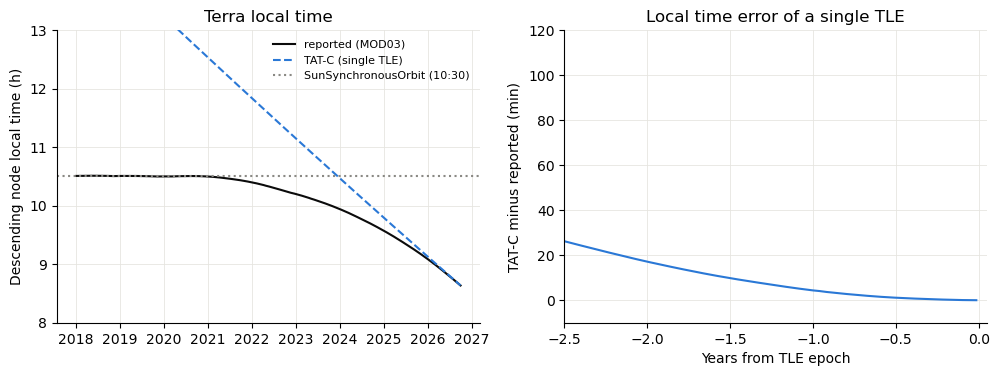

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(crossings.time, crossings["local time (h)"], color=INK, label="reported (MOD03)")
axes[0].plot(crossings.time, crossings["TAT-C (TLE) local time (h)"], color=BLUE, ls="--", label="TAT-C (single TLE)")
axes[0].axhline(10.5, color=GRAY, ls=":", label="SunSynchronousOrbit (10:30)")
axes[0].set(ylabel="Descending node local time (h)", title="Terra local time", ylim=(8, 13))
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(crossings["years from TLE epoch"], crossings["TAT-C minus reported (min)"], color=BLUE)
axes[1].set(xlabel="Years from TLE epoch", ylabel="TAT-C minus reported (min)", title="Local time error of a single TLE", xlim=(-2.5, 0.05), ylim=(-10, 120))
plt.show()

Terra's local time stayed within 0.01 h of 10:30 until its last inclination adjustment in 2020. Since then, it has drifted earlier at an increasing rate, from about 6 minutes per year in 2021 to 36 minutes per year in 2026, reaching 8:52 in September 2026.

The TLE reproduces the current drift: over the last six months, its local time drifts by 39.5 minutes per year, compared with 37.3 minutes per year reported (the TLE's rate is that at its epoch, at the end of an accelerating drift), and its local times are within 0.3 minutes of the reported ones over the three months before its epoch. Further from its epoch, a single TLE departs from the actual drift: its local times differ by 1.1 minutes after six months, 4.4 minutes after one year, 17 minutes after two years, and an hour after four years. SGP4 propagates a near-Earth orbit with a constant inclination, so the drift rate stays at its value at the epoch, whereas the Sun's gravity continues to change Terra's inclination and accelerates the drift. A `SunSynchronousOrbit` keeps the design local time and does not drift at all. For analyses of more than a few months of a drifting orbit, TLEs closer to the analysis times (for example, a series of TLEs in a `GeneralPerturbationsOrbit`) are needed.

## Test 3: Scan Geometry

Each pixel's view angles are computed from Terra's reported position and velocity at the time of its scan with `compute_view_angles`: the roll (cross-track) angle, positive left, and the pitch (along-track) angle, positive forward, in both velocity frames. The scan angle of each frame is fitted as a linear function of the frame index, and the along-track angles of the first and last detectors give the along-track extent of a scan.

In [6]:
def view_angles(granule, step=40):
    rows = []
    for scan in np.nonzero(granule["valid"])[0][5::step]:
        track = ephemeris_track(granule, [scan])[0]
        for j in range(0, len(granule["frames"]), 4):
            values = {}
            for frame in VelocityFrame:
                angles = [compute_view_angles(track, wgs84.latlon(*(float(granule[k][r, j]) for k in ("latitude", "longitude", "height"))), velocity_frame=frame) for r in (2 * scan, 2 * scan + 1)]
                values[frame.value] = angles
            (r1, a1), (r10, a10) = values["inertial"]
            rows.append(
                {
                    "frame": int(granule["frames"][j]),
                    "roll (deg)": float((r1 + r10) / 2),
                    "pitch, inertial (deg)": float((a1 + a10) / 2),
                    "pitch, Earth-fixed (deg)": float(sum(a for _, a in values["earth_fixed"]) / 2),
                    "along-track extent, detectors 1 to 10 (deg)": float(a10 - a1),
                    "granule": granule["name"],
                }
            )
    return rows


angles = pd.DataFrame([row for rows in Parallel(n_jobs=-1)(delayed(view_angles)(g) for g in granules[::6]) for row in rows])
slope, offset = np.polyfit(angles.frame - 676.5, angles["roll (deg)"], 1)
angles["scan angle residual (deg)"] = angles["roll (deg)"] - (slope * (angles.frame - 676.5) + offset)
twist = angles.groupby("granule").apply(lambda g: pd.Series({frame: np.polyfit(g["roll (deg)"], g[f"pitch, {frame} (deg)"], 1)[0] for frame in ("inertial", "Earth-fixed")}))
print(f"roll = {slope:.5f} deg x (frame - 676.5) {offset:+.3f} deg; residual 95th percentile {angles['scan angle residual (deg)'].abs().quantile(0.95):.3f} deg")
print(f"scan angles {slope * -676.5 + offset:.2f} to {slope * 676.5 + offset:.2f} deg")
print("trend of the along-track angle across the scan (deg per deg of roll), by granule:")
print(twist.describe().loc[["mean", "std", "min", "max"]].round(5).to_string())
angles["scan angle bin (deg)"] = pd.cut(angles["roll (deg)"], [-56, -45, -30, -15, 0, 15, 30, 45, 56])
angles.groupby("scan angle bin (deg)", observed=True)[["pitch, inertial (deg)", "pitch, Earth-fixed (deg)", "along-track extent, detectors 1 to 10 (deg)"]].median().round(4).T

roll = 0.08124 deg x (frame - 676.5) -0.046 deg; residual 95th percentile 0.049 deg
scan angles -55.00 to 54.91 deg
trend of the along-track angle across the scan (deg per deg of roll), by granule:
      inertial  Earth-fixed
mean   0.00185      0.00217
std    0.00003      0.04346
min    0.00180     -0.05872
max    0.00189      0.06267


C:\Users\pgrogan\AppData\Local\Temp\ipykernel_10456\4133548599.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  twist = angles.groupby("granule").apply(lambda g: pd.Series({frame: np.polyfit(g["roll (deg)"], g[f"pitch, {frame} (deg)"], 1)[0] for frame in ("inertial", "Earth-fixed")}))


scan angle bin (deg),"(-56, -45]","(-45, -30]","(-30, -15]","(-15, 0]","(0, 15]","(15, 30]","(30, 45]","(45, 56]"
"pitch, inertial (deg)",-0.1007,-0.1011,-0.0837,-0.0498,-0.0126,0.0218,0.0498,0.0584
"pitch, Earth-fixed (deg)",-0.2081,-0.1894,-0.1359,-0.0525,-0.0233,0.0680,0.1293,0.1630
"along-track extent, detectors 1 to 10 (deg)",0.7311,0.7311,0.7311,0.7311,0.7311,0.7311,0.7311,0.7311


The scan angle increases by 0.08124 deg per frame (1.418 mrad, MODIS's nominal sampling), from -55.00 deg at frame 0 (on the right of the direction of motion) to +54.91 deg at frame 1,353 (on the left), within 0.05 deg (95th percentile). The scans are perpendicular to the inertial velocity: in the inertial frame, the along-track angle of the scan varies across the scan by the same amount in every granule (0.00185 deg per degree of scan angle), whereas in the Earth-fixed frame its variation changes from -0.06 to +0.06 deg per degree around the orbit. Terra, unlike PACE, is not yaw-steered. The constant variation in the inertial frame (0.1 deg at the swath edges) comes from the scan's duration: the mirror sweeps the Earth in about 0.45 s, during which Terra moves about 3 km, so the frames at the start of the scan (on the right) lie behind those at its end. The along-track angle between the first and last detectors is 0.731 deg (nine detector spacings of 0.0812 deg) at all scan angles, as in scan geometry.

A MODIS `PointedInstrument` is defined from these values: 1,354 pixels across track spanning 109.9 deg (1,354 frames of 0.0812 deg), 10 pixels along track spanning 0.812 deg (10 detectors of 0.0812 deg), the inertial velocity frame, and scan geometry. The positions of its first and last detectors at three frames of every scan are compared with the reported ones, using the reported orbit; and the along-track length of each scan footprint (from the outer edge of detector 1 to that of detector 10) is compared with the frame geometry, and with the advance of the ground track in one scan period.

In [7]:
modis = PointedInstrument(
    name="MODIS", field_of_regard=112, cross_track_field_of_view=1354 * 0.0812, along_track_field_of_view=10 * 0.0812,
    cross_track_pixels=1354, along_track_pixels=10, is_rectangular=True, view_geometry=ViewGeometry.SCAN, velocity_frame=VelocityFrame.INERTIAL,
)
modis_frame = modis.model_copy(update={"view_geometry": ViewGeometry.FRAME})


def pixel_errors(granule, step=20):
    rows = []
    sampled = list(granule["frames"])
    for scan in np.nonzero(granule["valid"])[0][3::step]:
        track = ephemeris_track(granule, [scan])[0]
        for frame in (0, 680, 1353):
            j = sampled.index(frame)
            # MODIS frames run right to left (frame 0 on the right); TAT-C's cross-track index 0 is also on the right
            for detector, r in ((0, 2 * scan), (9, 2 * scan + 1)):
                lat, lon = float(granule["latitude"][r, j]), float(granule["longitude"][r, j])
                height = float(granule["height"][r, j])
                # TAT-C's along-track index 0 is the most forward detector (detector 10)
                pixel = modis.compute_projected_pixel_position(track, frame, 9 - detector, elevation=height)
                rows.append({"frame": frame, "detector": detector + 1, "distance (km)": geodesic_distance(lon, lat, pixel.longitude.degrees, pixel.latitude.degrees) / 1e3})
        # scan footprint lengths along track at nadir and the edges
        for frame in (0, 680, 1353):
            j = sampled.index(frame)
            first, last = ((float(granule["latitude"][r, j]), float(granule["longitude"][r, j])) for r in (2 * scan, 2 * scan + 1))
            observed = geodesic_distance(first[1], first[0], last[1], last[0]) / 1e3 * 10 / 9
            lengths = {}
            for label, instrument in (("scan geometry", modis), ("frame geometry", modis_frame)):
                ends = [instrument.compute_projected_pixel_position(track, frame, k) for k in (0, 9)]
                lengths[label] = geodesic_distance(ends[0].longitude.degrees, ends[0].latitude.degrees, ends[1].longitude.degrees, ends[1].latitude.degrees) / 1e3 * 10 / 9
            rows.append({"frame": frame, "scan length (km)": observed, "TAT-C scan geometry length (km)": lengths["scan geometry"], "TAT-C frame geometry length (km)": lengths["frame geometry"]})
    return rows


pixels = pd.DataFrame([row for rows in Parallel(n_jobs=-1)(delayed(pixel_errors)(g) for g in granules[::4]) for row in rows])
position = pixels.dropna(subset=["distance (km)"]).groupby(["frame", "detector"])["distance (km)"].describe(percentiles=[0.5, 0.95])[["count", "50%", "95%", "max"]]
print(position.round(2).to_string())
lengths = pixels.dropna(subset=["scan length (km)"]).groupby("frame")[["scan length (km)", "TAT-C scan geometry length (km)", "TAT-C frame geometry length (km)"]].median()
lengths["ground track advance per scan (km)"] = 1.477 * 6.75
lengths.round(2)

                count   50%   95%   max
frame detector                         
0     1.0       737.0  5.36  8.03  8.21
      10.0      737.0  5.27  7.85  8.03
680   1.0       737.0  1.53  2.59  2.71
      10.0      737.0  1.53  2.59  2.70
1353  1.0       737.0  2.91  4.83  5.00
      10.0      737.0  2.93  4.72  4.89


,scan length (km),TAT-C scan geometry length (km),TAT-C frame geometry length (km),ground track advance per scan (km)
frame,,,,
0,19.88,19.82,16.92,9.97
680,9.92,9.92,9.92,9.97
1353,19.79,19.82,16.92,9.97


With Terra's reported position and velocity, the scan-geometry `PointedInstrument` places the first and last detectors within 1.5 km of the reported pixels at nadir (median), 2.9 km at the left edge, and 5.3 km at the right edge, where the scan starts; the differences at the edges come from the scan's duration (about 1.5 km) and a roll offset of 0.05 deg, which TAT-C does not model. Its scan footprints have the observed along-track length: 9.9 km at nadir and 19.8 km at the edges (19.9 km observed), twice the nadir length (the bow tie effect), whereas a frame-geometry view would give 16.9 km at the edges.

## Test 4: Daily Observations

The points of interest are those of a Fibonacci lattice with a typical spacing of 500 km. For each point and each MODIS pass over it, the observation time is the time of the scan through the point, interpolated between scans from the nearest sampled pixel (within 30 km, excluding the outermost sampled frames). `collect_observations` predicts the observations of the MODIS `PointedInstrument` above with the TLE orbit over the same day.

In [8]:
lattice = generate_points_fibonacci_lattice(500e3)
points = [Point(id=int(r.point_id), latitude=r.geometry.y, longitude=r.geometry.x) for r in lattice.itertuples()]
pixel_xyz, pixel_index = [], []
for gi, g in enumerate(granules):
    for r in range(0, len(g["rows"]), 2):
        scan = r // 2
        if not g["valid"][scan]:
            continue
        valid = np.isfinite(g["latitude"][r])
        xyz = wgs84.latlon(g["latitude"][r][valid], g["longitude"][r][valid], g["height"][r][valid]).itrs_xyz.m.T
        pixel_xyz.append(xyz)
        pixel_index.append(np.column_stack([np.full(valid.sum(), gi), np.full(valid.sum(), scan), np.nonzero(valid)[0]]))
pixel_xyz, pixel_index = np.concatenate(pixel_xyz), np.concatenate(pixel_index)
tree = cKDTree(pixel_xyz)
reference = []
for point in points:
    xyz = np.array(wgs84.latlon(point.latitude, point.longitude).itrs_xyz.m)
    nearby = tree.query_ball_point(xyz, 30e3)
    if not nearby:
        continue
    candidates = pd.DataFrame(pixel_index[nearby], columns=["granule", "scan", "column"]).assign(distance=np.linalg.norm(pixel_xyz[nearby] - xyz, axis=1))
    candidates["time"] = [scan_times(granules[g], [s]).utc_datetime()[0] for g, s in zip(candidates.granule, candidates.scan)]
    candidates = candidates.sort_values("time")
    for _, group in candidates.groupby((candidates.time.diff().dt.total_seconds() > 600).cumsum()):
        best = group.loc[group.distance.idxmin()]
        g, s, c = granules[int(best.granule)], int(best.scan), int(best.column)
        if c in (0, len(g["frames"]) - 1):
            continue
        s0, s1 = (s, s + 1) if s + 1 < len(g["ev_center_time"]) else (s - 1, s)
        x0, x1 = (np.array(wgs84.latlon(g["latitude"][2 * k, c], g["longitude"][2 * k, c]).itrs_xyz.m) for k in (s0, s1))
        fraction = float(np.dot(xyz - x0, x1 - x0) / np.dot(x1 - x0, x1 - x0))
        t0, t1 = (scan_times(g, [k]).utc_datetime()[0] for k in (s0, s1))
        reference.append({"point_id": point.id, "latitude": point.latitude, "time": pd.Timestamp(t0) + (pd.Timestamp(t1) - pd.Timestamp(t0)) * fraction, "frame": int(g["frames"][c])})
reference = pd.DataFrame(reference)


def observe(point):
    return collect_observations(point, Satellite(name="Terra", orbit=orbit, instruments=[modis]), DAY, DAY + timedelta(days=1))


predicted = pd.concat([f for f in Parallel(n_jobs=-1)(delayed(observe)(point) for point in points) if not f.empty])
merged = pd.merge_asof(
    reference.sort_values("time"), predicted[["point_id", "epoch"]].sort_values("epoch"),
    left_on="time", right_on="epoch", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=3),
)
merged["difference (s)"] = (merged.epoch - merged.time).dt.total_seconds()
found = pd.merge_asof(
    predicted.sort_values("epoch"), reference[["point_id", "time"]].sort_values("time"),
    left_on="epoch", right_on="time", by="point_id", direction="nearest", tolerance=pd.Timedelta(minutes=3),
)
covered = reference.point_id.nunique()
pd.Series(
    {
        "points": len(points),
        "points observed by MODIS": covered,
        "points observed by TAT-C": predicted.point_id.nunique(),
        "MODIS observations": len(reference),
        "matched by TAT-C (%)": 100 * merged.epoch.notna().mean(),
        "time difference, median (s)": merged["difference (s)"].abs().median(),
        "time difference, 95th percentile (s)": merged["difference (s)"].abs().quantile(0.95),
        "time difference, max (s)": merged["difference (s)"].abs().max(),
        "TAT-C observations": len(predicted),
        "found in MODIS data (%)": 100 * found.time.notna().mean(),
    }
).round(2)

points                                  2598.00
points observed by MODIS                2568.00
points observed by TAT-C                2572.00
MODIS observations                      6826.00
matched by TAT-C (%)                      99.63
time difference, median (s)                0.26
time difference, 95th percentile (s)       0.70
time difference, max (s)                   1.19
TAT-C observations                      6867.00
found in MODIS data (%)                   99.04
dtype: float64

`collect_observations` predicts MODIS's observations: 99.6% of the 6,826 passes over the points are matched by a predicted observation, within 0.26 s (median) and 1.2 s (maximum), and 99.0% of the predicted observations are found in the MODIS data. The remaining differences are at the swath edges, where the sampled pixels are sparse, and at the ends of the day. MODIS observes 99% of the points in a day (2,568 of 2,598); the others lie in the gaps between adjacent swaths near the equator, which TAT-C also predicts (2,572 points observed).

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (TLE) | 7.6 km along track (1.1 s) two days before the TLE epoch; within 0.35 km across track and radially |
| 2. Local time drift | a single TLE reproduces the current drift (39.5 vs. 37.3 minutes per year) and local times within 0.3 minutes over three months, but departs by 4.4 minutes after one year and an hour after four years, as SGP4 keeps the inclination constant |
| 3. Scan geometry (`ViewGeometry.SCAN`, `VelocityFrame.INERTIAL`) | scan angles 0.0812 deg per frame; scans perpendicular to the inertial velocity; constant along-track extent (0.731 deg between the first and last detectors); pixels within 1.5 km at nadir and 3 to 5 km at the edges; scan footprints 9.9 km long at nadir and 19.8 km at the edges (19.9 km observed) |
| 4. Daily observations (`collect_observations`) | 99.6% of passes matched, within 0.26 s (median); 99.0% of predicted observations found |

**Scan geometry.** A `PointedInstrument` in scan geometry with the inertial velocity frame reproduces MODIS's scans, including their growth along track toward the swath edges, confirming the VIIRS validation for a second scanner and a spacecraft without yaw steering.

**Drifting orbits.** TAT-C propagates a TLE with SGP4, which reproduces the local time drift of Terra's unmaintained orbit near the TLE's epoch, but not its acceleration: SGP4 keeps a near-Earth orbit's inclination constant, while the Sun's gravity changes it. Analyses of a drifting orbit over more than a few months should use TLEs near the analysis times. A `SunSynchronousOrbit` represents the maintained orbit that Terra flew until 2020.

**Limitations.** TAT-C treats each scan as instantaneous; MODIS's 0.45 s sweep shifts the pixels at the swath edges by about 1.5 km along track.